### Packages

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Plotting / Formatting
import matplotlib as mpl
import matplotlib.pyplot as plt
from mplsoccer import FontManager
from adjustText import adjust_text
import matplotlib.ticker as ticker
import matplotlib.patheffects as path_effects
import matplotlib.patches as patches
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib import cm
from highlight_text import fig_text, ax_text

# Standardization/normalization of data
from scipy.stats import zscore, norm
import scipy.stats as st

# Date formatting
import datetime
from itertools import islice

## Import and load data first

I have set up my code to be inline with how my folders are set up in terms of dates, etc. when pulling/saving/exporting dataframes and output. feel free to adjust code to match how you organize your folders

There is one manual step that involves exporting the data from Soccerment each week to get updated data. Long term i would hope to potentially build a web scraper to skip this step.

In [4]:
############################################################################################################################
# UPDATE WITH DATE OF NEW FOLDER
# this variable will go into the file path you save the main df as
folder_date = '2022.09.22'
############################################################################################################################

# Load data; I export updated data files from Soccerment 
# if someone is good at scraping and can build a program to skip this manual step let me know!
df1 = pd.read_csv(f'Data/{folder_date}/soccerment - premier-league.csv')
df2 = pd.read_csv(f'Data/{folder_date}/soccerment - bundesliga.csv')
df3 = pd.read_csv(f'Data/{folder_date}/soccerment - la-liga.csv')
df4 = pd.read_csv(f'Data/{folder_date}/soccerment - ligue-1.csv')
df5 = pd.read_csv(f'Data/{folder_date}/soccerment - eredivisie.csv')
df6 = pd.read_csv(f'Data/{folder_date}/soccerment - primeira.csv')
df7 = pd.read_csv(f'Data/{folder_date}/soccerment - serie-a.csv')

# create a list of dataframes and concatenate into one main df
# this helps make the data manipulation step easier
dfs = [df1,df2,df3,df4,df5,df6,df7]
df = pd.concat(dfs)

# create a variable as of today's date
date = f'{datetime.datetime.now().strftime("%m%d%Y")}'
df.to_csv(f'Data/{folder_date}/raw-data-{date}.csv')

## Some minor data wrangling to get the dfs cleaned and ready to standardize/plot

In [6]:
# set filter for matches played 
# I set a separate filter for la Liga as they have one less game than the rest of the leagues
# feel free to adjust minutes as needed # as of now 250-350 is my preference based on the number of matches player
mp = 300
mp_la_liga = 250

# some minor data cleaning and creation of new varaibales
df = df.copy()
df = df.dropna(axis=0, subset=['Role'])
df['xGoT'] = df['xGoT'].fillna(0) # for players that have not had a shot on target, they will have nan values for xGoT
df = df.loc[df['Position'] == 'Forward'] # Filter by position. Set up for forwards as advanced stats are not as applicable
df['xA_received'] = (df['npxG'] + df['xA']) - df['xOVA'] # metric used to measure positioning of forwards
df['xA_received_p90'] = (df['xA_received'] / df['Time Played'])*90
df['SGA2'] = df['xGoT'] - df['npxG'] # to help get rid of nan values for players w/o shots on target
df['SGA'].fillna(df['SGA2'], inplace=True)
df['SGA_p90'] = (df['SGA'] / df['Time Played'])*90
df['Team'] = np.where(df.Team.isin(['Borussia Mönchengladbach']),'Mönchengladbach', df['Team']) # table spacing purposes

# now that data is cleaned we can go back take each league and create a df for each
# create an array of each league name to use for the for loop below
leagues = df.League.unique()
league_dfs = []

# loop through the full df by pulling data of each league and create a list of each df for each league
for league in leagues:
    lg = df[df['League'] == league]
    league_dfs.append(lg)    

# UPDATE MINUTES APPROPRIATELY (La liga has 1 less game than all)
# index key for each league beside each row
league_dfs[0] = league_dfs[0][league_dfs[0]['Time Played'] >= mp ] # BPL = 0
league_dfs[1] = league_dfs[1][league_dfs[1]['Time Played'] >= mp ] # BUNDESLIGA = 1
league_dfs[2] = league_dfs[2][league_dfs[2]['Time Played'] >= mp_la_liga ] # LA LIGA = 2
league_dfs[3] = league_dfs[3][league_dfs[3]['Time Played'] >= mp ] # LIGUE 1 = 3
league_dfs[4] = league_dfs[4][league_dfs[4]['Time Played'] >= mp ] # EREDIVISIE = 4
league_dfs[5] = league_dfs[5][league_dfs[5]['Time Played'] >= mp ] # PRIMEIRA = 5
league_dfs[6] = league_dfs[6][league_dfs[6]['Time Played'] >= mp ] # SERIE A = 6

### Run this block to standardize, normalize and scale the data to 100; building block for the rankings

I used Liam Henshaw's (Twitter: @HenshawAnalysis) methodology for rating players using the advanced metrics from Soccerment. See link below for a detailed explanation on the functions used and thought process behind the methodology.

https://henshawanalysis.medium.com/henshaw-analysis-player-ratings-methodology-discussion-examples-555351393b9a

#### Index Key for each League
- BPL = 0
- BUNDESLIGA = 1
- LA LIGA = 2
- LIGUE 1 = 3
- EREDIVISIE = 4
- PRIMEIRA = 5
- SERIE A = 6

In [7]:
# create a copy of the list of dfs and drop all irrelevant columnns to create a model df
model_leagues = league_dfs.copy()
model_leagues = [league.drop(['Team', 'League', 'season', 'Age', 'Position', 'Role', 'Appearances', 'Time Played', 'Goals', 'Goals_p90', 'xG', 'xG_p90', 'npxG', 'xGoT', 'xGoTA', 'SGA', 'Goals prevented per xGoT', 'Assists', 'Assists_p90', 'xA', 'xA_p90', 'opxA', 'opxA_p90', 'xOVA', 'xThreat', 'xThreat from passes', 'xThreat from passes_p90', 'xThreat from carries', 'xThreat from carries_p90', 'SGA2', 'xA_received'], axis=1) for league in model_leagues]

# next steps are to standardize, normalize, and scale the data to 100 (per Liam Henshaw method)
# BPL (set index to 0, as stated in key above)
norm_bpl = model_leagues[0]

# zscore function used to calc position of each raw score in terms of standard deviations from mean 
# mean being 0 and standard deviations +/- from the mean
norm_bpl = (norm_bpl.select_dtypes(exclude='object')
           .apply(zscore) 
           .join(norm_bpl.select_dtypes(include='object')))  

# norm.cdf normalizes the zscores to be between 0 and 1 (mean as 0.50)
norm_bpl = (norm_bpl.select_dtypes(exclude='object')
           .apply(norm.cdf)
           .join(norm_bpl.select_dtypes(include='object')))

# this step sclaes each metric to 100 for visualization and rating purposes
norm_bpl[['xA_received_p90', 'npxG_p90', 'SGA_p90', 'xOVA_p90', 'xThreat_p90']] = round(norm_bpl[['xA_received_p90', 'npxG_p90', 'SGA_p90', 'xOVA_p90', 'xThreat_p90']] *100,1)

# copy df and name as final data for rankings
ranked_bpl = norm_bpl.copy()

# rename columns as will be shown in table
ranked_bpl = ranked_bpl.rename({'xA_received_p90': 'Positioning',
                                'npxG_p90': 'Goal Scoring',
                                'SGA_p90': 'Finishing',
                                'xOVA_p90': 'Contribution Added',
                                'xThreat_p90': 'Threat Creation'}, axis=1)

# now that we have ratings for each metric we can create and overal rating for each player and overall rank
# overall ratings uses a weighted average approach; currently equally weighting each attribute
# feel free to adjust weights to reflect whatever attributes you feel are more important
ranked_bpl['Rating'] = ranked_bpl['Positioning']*0.2 + ranked_bpl['Goal Scoring']*0.2 + ranked_bpl['Finishing']*0.2 + ranked_bpl['Contribution Added']*0.2 + ranked_bpl['Threat Creation']*0.2
ranked_bpl = ranked_bpl.sort_values(by=['Rating'], ascending=True)
ranked_bpl['Rank'] = list(range(1, len(ranked_bpl)+1))[::-1]

# final step is to create a new variable matching each player with respective team
teams = league_dfs.copy()
teams = [team.drop(['xA_received_p90', 'npxG_p90', 'SGA_p90', 'xOVA_p90', 'xThreat_p90', 'League', 'season', 'Age', 'Position', 'Role', 'Appearances', 'Time Played', 'Goals', 'Goals_p90', 'xG', 'xG_p90', 'npxG', 'xGoT', 'xGoTA', 'SGA', 'Goals prevented per xGoT', 'Assists', 'Assists_p90', 'xA', 'xA_p90', 'opxA', 'opxA_p90', 'xOVA', 'xThreat', 'xThreat from passes', 'xThreat from passes_p90', 'xThreat from carries', 'xThreat from carries_p90', 'SGA2', 'xA_received'], axis=1) for team in teams]
ranked_bpl = pd.merge(ranked_bpl, teams[0], on='Full Name', how='outer')
ranked_bpl['League'] = leagues[0]
ranked_bpl = ranked_bpl[['Full Name', 'Team', 'League', 'Rank', 'Rating', 'Positioning', 'Goal Scoring', 'Finishing', 'Contribution Added', 'Threat Creation']]

# export full df
ranked_bpl.to_csv(f'Rankings/rankings-bpl-{date}.csv')
ranked_bpl_10 = ranked_bpl.tail(10)

# REPEAT STEPS FOR EACH LEAGUE

# Bundesliga
norm_bundesliga = model_leagues[1]

norm_bundesliga = (norm_bundesliga.select_dtypes(exclude='object')
                   .apply(zscore)
                   .join(norm_bundesliga.select_dtypes(include='object')))  

norm_bundesliga = (norm_bundesliga.select_dtypes(exclude='object')
                  .apply(norm.cdf)
                  .join(norm_bundesliga.select_dtypes(include='object')))

norm_bundesliga[['xA_received_p90', 'npxG_p90', 'SGA_p90', 'xOVA_p90', 'xThreat_p90']] = round(norm_bundesliga[['xA_received_p90', 'npxG_p90', 'SGA_p90', 'xOVA_p90', 'xThreat_p90']] *100,1)

ranked_bundesliga = norm_bundesliga.copy()
ranked_bundesliga = ranked_bundesliga.rename({'xA_received_p90': 'Positioning',
                                              'npxG_p90': 'Goal Scoring',
                                              'SGA_p90': 'Finishing',
                                              'xOVA_p90': 'Contribution Added',
                                              'xThreat_p90': 'Threat Creation'}, axis=1)

ranked_bundesliga['Rating'] = ranked_bundesliga['Positioning']*0.2 + ranked_bundesliga['Goal Scoring']*0.2 + ranked_bundesliga['Finishing']*0.2 + ranked_bundesliga['Contribution Added']*0.2 + ranked_bundesliga['Threat Creation']*0.2
ranked_bundesliga = ranked_bundesliga.sort_values(by=['Rating'], ascending=True)
ranked_bundesliga['Rank'] = list(range(1, len(ranked_bundesliga)+1))[::-1]
    
ranked_bundesliga = pd.merge(ranked_bundesliga, teams[1], on='Full Name', how='outer')
ranked_bundesliga['League'] = leagues[1]
ranked_bundesliga = ranked_bundesliga[['Full Name', 'Team', 'League', 'Rank', 'Rating', 'Positioning', 'Goal Scoring', 'Finishing', 'Contribution Added', 'Threat Creation']]
ranked_bundesliga.to_csv(f'Rankings/rankings-bundesliga-{date}.csv')
ranked_bundesliga_10 = ranked_bundesliga.tail(10)

# La Liga
norm_la_liga = model_leagues[2]

norm_la_liga = (norm_la_liga.select_dtypes(exclude='object')
                .apply(zscore)
                .join(norm_la_liga.select_dtypes(include='object')))  

norm_la_liga = (norm_la_liga.select_dtypes(exclude='object')
                .apply(norm.cdf)
                .join(norm_la_liga.select_dtypes(include='object')))

norm_la_liga[['xA_received_p90', 'npxG_p90', 'SGA_p90', 'xOVA_p90', 'xThreat_p90']] = round(norm_la_liga[['xA_received_p90', 'npxG_p90', 'SGA_p90', 'xOVA_p90', 'xThreat_p90']] *100,1)

ranked_la_liga = norm_la_liga.copy()
ranked_la_liga = ranked_la_liga.rename({'xA_received_p90': 'Positioning',
                                        'npxG_p90': 'Goal Scoring',
                                        'SGA_p90': 'Finishing',
                                        'xOVA_p90': 'Contribution Added',
                                        'xThreat_p90': 'Threat Creation'}, axis=1)

ranked_la_liga['Rating'] = ranked_la_liga['Positioning']*0.2 + ranked_la_liga['Goal Scoring']*0.2 + ranked_la_liga['Finishing']*0.2 + ranked_la_liga['Contribution Added']*0.2 + ranked_la_liga['Threat Creation']*0.2
ranked_la_liga = ranked_la_liga.sort_values(by=['Rating'], ascending=True)
ranked_la_liga['Rank'] = list(range(1, len(ranked_la_liga)+1))[::-1]
    
ranked_la_liga = pd.merge(ranked_la_liga, teams[2], on='Full Name', how='outer')
ranked_la_liga['League'] = leagues[2]
ranked_la_liga = ranked_la_liga[['Full Name', 'Team', 'League', 'Rank', 'Rating', 'Positioning', 'Goal Scoring', 'Finishing', 'Contribution Added', 'Threat Creation']]

ranked_la_liga.to_csv(f'Rankings/rankings-la-liga-{date}.csv')
ranked_la_liga_10 = ranked_la_liga.tail(10)

# Ligue 1
norm_ligue_1 = model_leagues[3]

norm_ligue_1 = (norm_ligue_1.select_dtypes(exclude='object')
                .apply(zscore)
                .join(norm_ligue_1.select_dtypes(include='object')))  

norm_ligue_1 = (norm_ligue_1.select_dtypes(exclude='object')
                .apply(norm.cdf)
                .join(norm_ligue_1.select_dtypes(include='object')))

norm_ligue_1[['xA_received_p90', 'npxG_p90', 'SGA_p90', 'xOVA_p90', 'xThreat_p90']] = round(norm_ligue_1[['xA_received_p90', 'npxG_p90', 'SGA_p90', 'xOVA_p90', 'xThreat_p90']] *100,1)

ranked_ligue_1 = norm_ligue_1.copy()
ranked_ligue_1 = ranked_ligue_1.rename({'xA_received_p90': 'Positioning',
                                        'npxG_p90': 'Goal Scoring',
                                        'SGA_p90': 'Finishing',
                                        'xOVA_p90': 'Contribution Added',
                                        'xThreat_p90': 'Threat Creation'}, axis=1)

ranked_ligue_1['Rating'] = ranked_ligue_1['Positioning']*0.2 + ranked_ligue_1['Goal Scoring']*0.2 + ranked_ligue_1['Finishing']*0.2 + ranked_ligue_1['Contribution Added']*0.2 + ranked_ligue_1['Threat Creation']*0.2
ranked_ligue_1 = ranked_ligue_1.sort_values(by=['Rating'], ascending=True)
ranked_ligue_1['Rank'] = list(range(1, len(ranked_ligue_1)+1))[::-1]
    
ranked_ligue_1 = pd.merge(ranked_ligue_1, teams[3], on='Full Name', how='outer')
ranked_ligue_1['League'] = leagues[3]
ranked_ligue_1 = ranked_ligue_1[['Full Name', 'Team', 'League', 'Rank', 'Rating', 'Positioning', 'Goal Scoring', 'Finishing', 'Contribution Added', 'Threat Creation']]
ranked_ligue_1.to_csv(f'Rankings/rankings-ligue-1-{date}.csv')
ranked_ligue_1_10 = ranked_ligue_1.tail(10)

# Eredivisie
norm_eredivisie = model_leagues[4]

norm_eredivisie = (norm_eredivisie.select_dtypes(exclude='object')
                  .apply(zscore)
                  .join(norm_eredivisie.select_dtypes(include='object')))  

norm_eredivisie = (norm_eredivisie.select_dtypes(exclude='object')
                   .apply(norm.cdf)
                   .join(norm_eredivisie.select_dtypes(include='object')))

norm_eredivisie[['xA_received_p90', 'npxG_p90', 'SGA_p90', 'xOVA_p90', 'xThreat_p90']] = round(norm_eredivisie[['xA_received_p90', 'npxG_p90', 'SGA_p90', 'xOVA_p90', 'xThreat_p90']] *100,1)

ranked_eredivisie = norm_eredivisie.copy()
ranked_eredivisie = ranked_eredivisie.rename({'xA_received_p90': 'Positioning',
                                              'npxG_p90': 'Goal Scoring',
                                              'SGA_p90': 'Finishing',
                                              'xOVA_p90': 'Contribution Added',
                                              'xThreat_p90': 'Threat Creation'}, axis=1)

ranked_eredivisie['Rating'] = ranked_eredivisie['Positioning']*0.2 + ranked_eredivisie['Goal Scoring']*0.2 + ranked_eredivisie['Finishing']*0.2 + ranked_eredivisie['Contribution Added']*0.2 + ranked_eredivisie['Threat Creation']*0.2
ranked_eredivisie = ranked_eredivisie.sort_values(by=['Rating'], ascending=True)
ranked_eredivisie['Rank'] = list(range(1, len(ranked_eredivisie)+1))[::-1]
    
ranked_eredivisie = pd.merge(ranked_eredivisie, teams[4], on='Full Name', how='outer')
ranked_eredivisie['League'] = leagues[4]
ranked_eredivisie = ranked_eredivisie[['Full Name', 'Team', 'League', 'Rank', 'Rating', 'Positioning', 'Goal Scoring', 'Finishing', 'Contribution Added', 'Threat Creation']]
ranked_eredivisie.to_csv(f'Rankings/rankings-eredivisie-{date}.csv')
ranked_eredivisie_10 = ranked_eredivisie.tail(10)

# Primeira
norm_primeira = model_leagues[5]

norm_primeira = (norm_primeira.select_dtypes(exclude='object')
                 .apply(zscore)
                 .join(norm_primeira.select_dtypes(include='object')))  

norm_primeira = (norm_primeira.select_dtypes(exclude='object')
                 .apply(norm.cdf)
                 .join(norm_primeira.select_dtypes(include='object')))

norm_primeira[['xA_received_p90', 'npxG_p90', 'SGA_p90', 'xOVA_p90', 'xThreat_p90']] = round(norm_primeira[['xA_received_p90', 'npxG_p90', 'SGA_p90', 'xOVA_p90', 'xThreat_p90']] *100,1)

ranked_primeira = norm_primeira.copy()
ranked_primeira = ranked_primeira.rename({'xA_received_p90': 'Positioning',
                                          'npxG_p90': 'Goal Scoring',
                                          'SGA_p90': 'Finishing',
                                          'xOVA_p90': 'Contribution Added',
                                          'xThreat_p90': 'Threat Creation'}, axis=1)

ranked_primeira['Rating'] = ranked_primeira['Positioning']*0.2 + ranked_primeira['Goal Scoring']*0.2 + ranked_primeira['Finishing']*0.2 + ranked_primeira['Contribution Added']*0.2 + ranked_primeira['Threat Creation']*0.2
ranked_primeira = ranked_primeira.sort_values(by=['Rating'], ascending=True)
ranked_primeira['Rank'] = list(range(1, len(ranked_primeira)+1))[::-1]
    
ranked_primeira = pd.merge(ranked_primeira, teams[5], on='Full Name', how='outer')
ranked_primeira['League'] = leagues[5]
ranked_primeira = ranked_primeira[['Full Name', 'Team', 'League', 'Rank', 'Rating', 'Positioning', 'Goal Scoring', 'Finishing', 'Contribution Added', 'Threat Creation']]
ranked_primeira.to_csv(f'Rankings/rankings-primeira-{date}.csv')
ranked_primeira_10 = ranked_primeira.tail(10)

# Serie A
norm_serie_a = model_leagues[6]

norm_serie_a = (norm_serie_a.select_dtypes(exclude='object')
                .apply(zscore)
                .join(norm_serie_a.select_dtypes(include='object')))  

norm_serie_a = (norm_serie_a.select_dtypes(exclude='object')
                .apply(norm.cdf)
                .join(norm_serie_a.select_dtypes(include='object')))

norm_serie_a[['xA_received_p90', 'npxG_p90', 'SGA_p90', 'xOVA_p90', 'xThreat_p90']] = round(norm_serie_a[['xA_received_p90', 'npxG_p90', 'SGA_p90', 'xOVA_p90', 'xThreat_p90']] *100,1)

ranked_serie_a = norm_serie_a.copy()
ranked_serie_a = ranked_serie_a.rename({'xA_received_p90': 'Positioning',
                                        'npxG_p90': 'Goal Scoring',
                                        'SGA_p90': 'Finishing',
                                        'xOVA_p90': 'Contribution Added',
                                        'xThreat_p90': 'Threat Creation'}, axis=1)

ranked_serie_a['Rating'] = ranked_serie_a['Positioning']*0.2 + ranked_serie_a['Goal Scoring']*0.2 + ranked_serie_a['Finishing']*0.2 + ranked_serie_a['Contribution Added']*0.2 + ranked_serie_a['Threat Creation']*0.2
ranked_serie_a = ranked_serie_a.sort_values(by=['Rating'], ascending=True)
ranked_serie_a['Rank'] = list(range(1, len(ranked_serie_a)+1))[::-1]
    
ranked_serie_a = pd.merge(ranked_serie_a, teams[6], on='Full Name', how='outer')
ranked_serie_a['League'] = leagues[6]
ranked_serie_a = ranked_serie_a[['Full Name', 'Team', 'League', 'Rank', 'Rating', 'Positioning', 'Goal Scoring', 'Finishing', 'Contribution Added', 'Threat Creation']]
ranked_serie_a.to_csv(f'Rankings/rankings-serie-a-{date}.csv')
ranked_serie_a_10 = ranked_serie_a.tail(10)

# concatenate all dfs in one df
ranked_dfs = [ranked_bpl, ranked_bundesliga, ranked_la_liga, ranked_ligue_1, ranked_eredivisie, 
              ranked_primeira, ranked_serie_a]
ranked_df = pd.concat(ranked_dfs)

## Run this block to create a new set of dataframes with the changes in ranks and ratings
### Make sure to update the last gameweek date to import data from the previous time it was run

In [340]:
############################################################################################################################
# update last gameweek run date to import data from previous week
last_gw_date = '09122022'
############################################################################################################################

# import and load previous gameweek data
ranked_bpl_previous = pd.read_csv(f'Rankings/rankings-bpl-{last_gw_date}.csv')
ranked_bundesliga_previous = pd.read_csv(f'Rankings/rankings-bundesliga-{last_gw_date}.csv')
ranked_la_liga_previous = pd.read_csv(f'Rankings/rankings-la-liga-{last_gw_date}.csv')
ranked_ligue_1_previous = pd.read_csv(f'Rankings/rankings-ligue-1-{last_gw_date}.csv')
ranked_eredivisie_previous = pd.read_csv(f'Rankings/rankings-eredivisie-{last_gw_date}.csv')
ranked_primeira_previous = pd.read_csv(f'Rankings/rankings-primeira-{last_gw_date}.csv')
ranked_serie_a_previous = pd.read_csv(f'Rankings/rankings-serie-a-{last_gw_date}.csv')

ranked_dfs_previous = [ranked_bpl_previous, ranked_bundesliga_previous, ranked_la_liga_previous,
                       ranked_ligue_1_previous, ranked_eredivisie_previous, ranked_primeira_previous, ranked_serie_a_previous]

# concat into one df to facilitate data manipulation; rename names of previous columns different to allow for calcs
ranked_df_previous = pd.concat(ranked_dfs_previous)
ranked_df_previous = ranked_df_previous[['Full Name', 'Rank', 'Rating', 'Positioning', 'Goal Scoring', 'Finishing', 'Contribution Added', 'Threat Creation']]
ranked_df_previous = ranked_df_previous.rename({'Positioning': 'Positioning_2',
                                                'Goal Scoring': 'Goal Scoring_2',
                                                'Finishing': 'Finsihing_2',
                                                'Contribution Added': 'Contribution Added_2',
                                                'Threat Creation': 'Threat Creation_2',
                                                'Rank': 'Rank_2',
                                                'Rating': 'Rating_2'}, axis=1)

# calcs for changes in ratings
ranking_change = pd.merge(ranked_df, ranked_df_previous, on='Full Name', how='outer')
ranking_change['rank_change'] = round(ranking_change['Rank_2'] - ranking_change['Rank'],1)
ranking_change['positioning_change'] = round(ranking_change['Positioning'] - ranking_change['Positioning_2'],1)
ranking_change['goal_scoring_change'] = round(ranking_change['Goal Scoring'] - ranking_change['Goal Scoring_2'],1)
ranking_change['finishing_change'] = round(ranking_change['Finishing'] - ranking_change['Finsihing_2'],1)
ranking_change['contribution_added_change'] = round(ranking_change['Contribution Added'] - ranking_change['Contribution Added_2'],1)
ranking_change['threat_change'] = round(ranking_change['Threat Creation'] - ranking_change['Threat Creation_2'],1)
ranking_change['rating_change'] = round(ranking_change['Rating'] - ranking_change['Rating_2'],1)

# create a new df with just the changes in rankings
ranking_change = ranking_change[['Full Name', 'Team', 'League', 'rank_change', 'rating_change', 'positioning_change', 'goal_scoring_change', 'finishing_change', 'contribution_added_change', 'threat_change']]
ranking_change

# as done previously, i like extracting each league and creating a list of dfs from main df
# make sure indexes of each df align with the respective league based on the league index listed in previous blocks
ranked_dfs_previous = []

for league in leagues:
    lg = ranking_change[ranking_change['League'] == league]
    ranked_dfs_previous.append(lg)  
    
#ranked_dfs_previous

## Run this block to plot the data get the final product

### ONE MANUAL UPDATE: Make sure to update index to match league you want to run for, matchweek for current week, and minutes to match what we filtered

### Table code based on @sonofacorners code. make sure to follow his tutorial on making tables using matplotlib!
https://twitter.com/sonofacorner/status/1571427558159110144?s=20&t=JYSkeJkvnDAbcXVYlRu3Xw

#### Index League Key

- BPL = 0
- BUNDESLIGA = 1
- LA LIGA = 2
- LIGUE 1 = 3
- EREDIVISIE = 4
- PRIMEIRA = 5
- SERIE A = 6

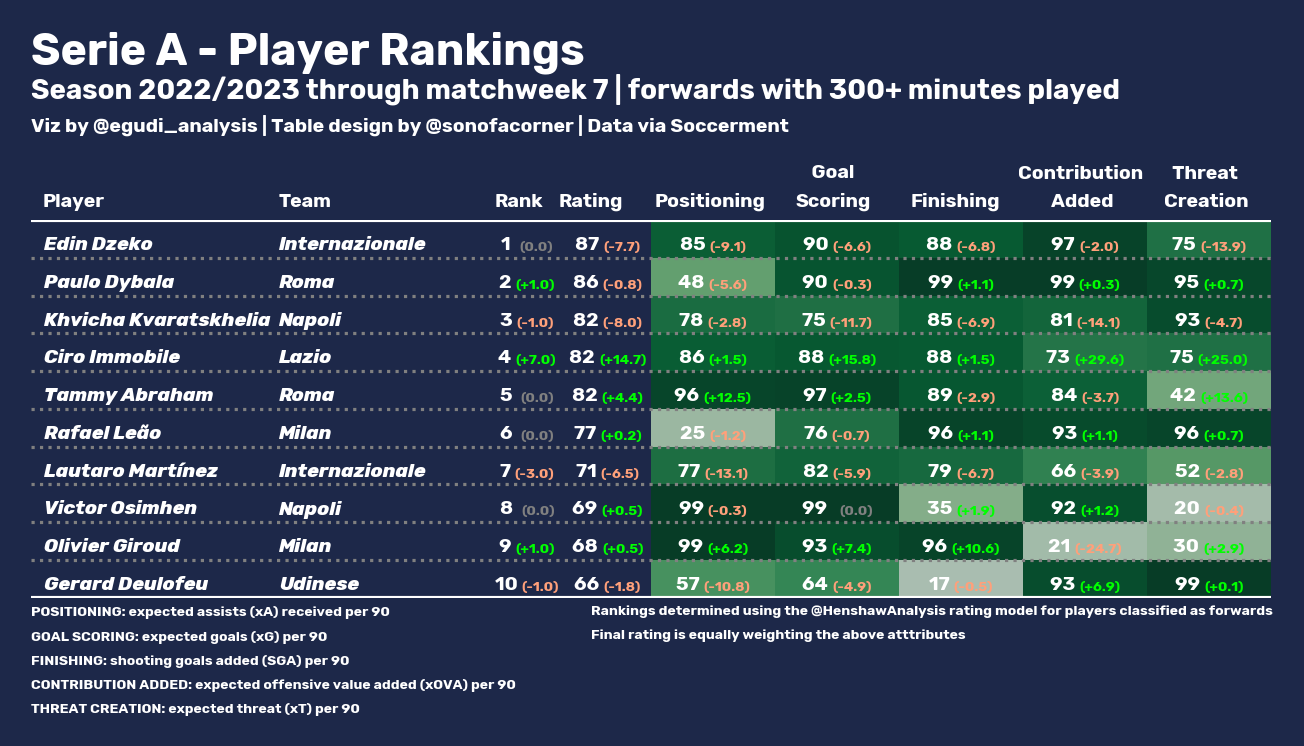

In [347]:
Rubik = FontManager('https://github.com/googlefonts/rubik/blob/main/fonts/ttf/Rubik-Bold.ttf?raw=true')
Rubik_italic = FontManager('https://github.com/googlefonts/rubik/blob/main/fonts/ttf/Rubik-ExtraBoldItalic.ttf?raw=true')
background = '#1d2849'
fontcolor = 'white'

###########################################################################################################################
# MANUAL UPDATES
# update index to match corresponding league
index = 6 

# update minutes/matchweek as appropriate
minutes = mp
matchweek = 7
############################################################################################################################

# create a df for titles of each league; order in same order as index league key
league_titles = ['English Premier League', 'Bundesliga', 'Spanish La Liga', 'French Ligue 1', 'Eredivisie',
                 'Portuguese Primeira Liga', 'Serie A']

ranked_dfs_10 = [ranked_bpl_10, ranked_bundesliga_10, ranked_la_liga_10, ranked_ligue_1_10, 
                 ranked_eredivisie_10, ranked_primeira_10, ranked_serie_a_10]

ranks = ranked_dfs[index].copy()
ranks = pd.merge(ranked_dfs_previous[index], ranks, on='Full Name', how='outer')
ranks_10 = ranks.tail(10)

# formatting used to save output as of current date
file_league = ['bpl', 'bundesliga', 'la-liga', 'ligue-1', 'eredivisie', 'primeira', 'serie-a']
date = f'{datetime.datetime.now().strftime("%m%d%Y")}'
folder_date = f'{datetime.datetime.now().strftime("%Y%m%d")}'

# set variables for each annotate
twitter_handle = '@egudi_analysis' # adjust with your handle
TITLE = f'{league_titles[index]} - Player Rankings'
TITLE2 = f'Season 2022/2023 through matchweek {matchweek} | forwards with {minutes}+ minutes played'
CREDIT = f'Viz by {twitter_handle} | Table design by @sonofacorner | Data via Soccerment'
NOTE = 'Rankings determined using the @HenshawAnalysis rating model for players classified as forwards'
NOTE2 = 'Final rating is equally weighting the above atttributes'
METRIC = 'POSITIONING: expected assists (xA) received per 90'
METRIC2 = 'GOAL SCORING: expected goals (xG) per 90'
METRIC3 = 'FINISHING: shooting goals added (SGA) per 90'
METRIC4 = 'CONTRIBUTION ADDED: expected offensive value added (xOVA) per 90'
METRIC5 = 'THREAT CREATION: expected threat (xT) per 90'

# create your figure
fig = plt.figure(figsize=(8, 2.5), dpi = 200)
fig.set_facecolor('#1d2849')
ax = plt.subplot(111, facecolor = "#1d2849")

ncols = 10 
nrows = ranked_dfs_10[index].shape[0]

ax.set_xlim(0, ncols)
ax.set_ylim(0, nrows)

# -- The CMAP fot the gradient
cmap = cm.get_cmap('Greens')

for y in range(nrows):
    # - player name
    x = 0.1
    player = ranks_10['Full Name'].iloc[y]
    label_ = f'{player}'
    ax.annotate(
        xy=(x,y+0.35),
        text=label_,
        ha='left',
        va='center',
        color='white',
        fontproperties=Rubik_italic.prop,
        fontsize=7
    )   
    # - team name
    x = 2
    team = ranks_10['Team_x'].iloc[y]
    label_ = f'{team}'
    ax.annotate(
        xy=(x,y+0.35),
        text=label_,
        ha='left',
        va='center',
        color='white',
        fontproperties=Rubik_italic.prop,
        fontsize=7
    )
    
    # -- rank
    rank = ranks_10['Rank'].iloc[y]
    rank_change = ranks_10['rank_change'].iloc[y]
    x = 4
    if rank_change < 0:
        high_color='#ffa07a'
        label_r = f'{int(rank)} <({(rank_change):.1f})>'
    elif rank_change == 0:
        high_color='gray'
        label_r = f'{int(rank)}  <({(rank_change):.1f})>'
    elif rank_change > 0:
        high_color='#00ff00'
        label_r = f'{int(rank)} <(+{(rank_change):.1f})>'
    else:
        high_color='#1d2849'
        label_r = f'{int(rank)} <(   -   )>'
    ax_text(
        x=x,y=y+0.35,
        s=label_r,
        ha='center',
        va='center',
        highlight_textprops=[{'size':5,'color':high_color}],
        size=7,
        ax=ax,
        color='w',
        fontproperties=Rubik.prop
    )
    
    # -- rating
    rating = ranks_10['Rating'].iloc[y]
    rating_change = ranks_10['rating_change'].iloc[y]
    x = 4.65
    if rating_change < 0:
        high_color='#ffa07a'
        label_rt = f'{int(rating)} <({(rating_change):.1f})>'
    elif rating_change == 0:
        high_color='gray'
        label_rt = f'{int(rating)}  <({(rating_change):.1f})>'
    elif rating_change > 0:
        high_color='#00ff00'
        label_rt = f'{int(rating)} <(+{(rating_change):.1f})>'
    else:
        high_color='#1d2849'
        label_rt = f'{int(rating)} <(   -   )>'
    ax_text(
        x=x,y=y+0.35,
        s=label_rt,
        ha='center',
        va='center',
        highlight_textprops=[{'size':5,'color':high_color}],
        size=7,
        ax=ax,
        color='w',
        fontproperties=Rubik.prop
    )
    
    # -- positioning
    positioning = ranks_10['Positioning'].iloc[y]
    positioning_change = ranks_10['positioning_change'].iloc[y]
    x = 5.5
    if positioning_change < 0:
        high_color='#ffa07a'
        label_p = f'{int(positioning)} <({(positioning_change):.1f})>'
    elif positioning_change == 0:
        high_color='gray'
        label_p = f'{int(positioning)}   <({(positioning_change):.1f})>'
    elif positioning_change > 0:
        high_color='#00ff00'
        label_p = f'{int(positioning)} <(+{(positioning_change):.1f})>'
    else:
        high_color='#1d2849'
        label_p = f'{int(positioning)}  <          >'
    ax_text(
        x=x,y=y+0.35,
        s=label_p,
        ha='center',
        va='center',
        highlight_textprops=[{'size':5,'color':high_color}],
        size=7,
        ax=ax,
        color='w',
        fontproperties=Rubik.prop
    )
    
    # -- Adding the colors
    # -- We subtract and add .5 beacause the width of our colum in 1, 1/2 = .5
    x = 5.5
    ax.fill_between(
        x=[(x - .5), (x + .5)],
        y1=y,
        y2=y + 1,
        color=cmap(positioning/100),
        zorder=2,
        ec="None",
        alpha=0.75
    )
    
    # -- goal_scoring
    goal_scoring = ranks_10['Goal Scoring'].iloc[y]
    goal_scoring_change = ranks_10['goal_scoring_change'].iloc[y]
    x = 6.5
    if goal_scoring_change < 0:
        high_color='#ffa07a'
        label_g = f'{int(goal_scoring)} <({(goal_scoring_change):.1f})>'
    elif goal_scoring_change == 0:
        high_color='gray'
        label_g = f'{int(goal_scoring)}   <({(goal_scoring_change):.1f})>'
    elif goal_scoring_change > 0:
        high_color='#00ff00'
        label_g = f'{int(goal_scoring)} <(+{(goal_scoring_change):.1f})>'
    else:
        high_color='#1d2849'
        label_g = f'{int(goal_scoring)}  <          >'
    ax_text(
        x=x,y=y+0.35,
        s=label_g,
        ha='center',
        va='center',
        highlight_textprops=[{'size':5,'color':high_color}],
        size=7,
        ax=ax,
        color='w',
        fontproperties=Rubik.prop
    )
    
    # -- Adding the colors
    x = 6.5
    ax.fill_between(
        x=[(x - .5), (x + .5)],
        y1=y,
        y2=y + 1,
        color=cmap(goal_scoring/100),
        zorder=2,
        ec="None",
        alpha=0.75
    )
    
    # -- finishing
    finishing = ranks_10['Finishing'].iloc[y]
    finishing_change = ranks_10['finishing_change'].iloc[y]
    x = 7.5
    if finishing_change < 0:
        high_color='#ffa07a'
        label_f = f'{int(finishing)} <({(finishing_change):.1f})>'
    elif finishing_change == 0:
        high_color='gray'
        label_f = f'{int(finishing)}   <({(finishing_change):.1f})>'
    elif finishing_change > 0:
        high_color='#00ff00'
        label_f = f'{int(finishing)} <(+{(finishing_change):.1f})>'
    else:
        high_color='#1d2849'
        label_f = f'{int(finishing)}  <          >'
    ax_text(
        x=x,y=y+0.35,
        s=label_f,
        ha='center',
        va='center',
        highlight_textprops=[{'size':5,'color':high_color}],
        size=7,
        ax=ax,
        color='w',
        fontproperties=Rubik.prop
    )
        
    # -- Adding the colors
    x = 7.5
    ax.fill_between(
        x=[(x - .5), (x + .5)],
        y1=y,
        y2=y + 1,
        color=cmap(finishing/100),
        zorder=2,
        ec="None",
        alpha=0.75
    )
    
    # -- contribution added
    contribution_added = ranks_10['Contribution Added'].iloc[y]
    contribution_added_change = ranks_10['contribution_added_change'].iloc[y]
    x = 8.5
    if contribution_added_change < 0:
        high_color='#ffa07a'
        label_c = f'{int(contribution_added)} <({(contribution_added_change):.1f})>'
    elif contribution_added_change == 0:
        high_color='gray'
        label_c = f'{int(contribution_added)}   <({(contribution_added_change):.1f})>'
    elif contribution_added_change > 0:
        high_color='#00ff00'
        label_c = f'{int(contribution_added)} <(+{(contribution_added_change):.1f})>'
    else:
        high_color='#1d2849'
        label_c = f'{int(contribution_added)}  <          >'
    ax_text(
        x=x,y=y+0.35,
        s=label_c,
        ha='center',
        va='center',
        highlight_textprops=[{'size':5,'color':high_color}],
        size=7,
        ax=ax,
        color='w',
        fontproperties=Rubik.prop
    )
    
    # -- Adding the colors
    x = 8.5
    ax.fill_between(
        x=[(x - .5), (x + .5)],
        y1=y,
        y2=y + 1,
        color=cmap(contribution_added/100),
        zorder=2,
        ec="None",
        alpha=0.75
    )
    
    # -- Threat Creation
    threat_creation = ranks_10['Threat Creation'].iloc[y]
    threat_creation_change = ranks_10['threat_change'].iloc[y]
    x = 9.5
    if threat_creation_change < 0:
        high_color='#ffa07a'
        label_t = f'{int(threat_creation)} <({(threat_creation_change):.1f})>'
    elif threat_creation_change == 0:
        high_color='gray'
        label_t = f'{int(threat_creation)}   <({(threat_creation_change):.1f})>'
    elif threat_creation_change > 0:
        high_color='#00ff00'
        label_t = f'{int(threat_creation)} <(+{(threat_creation_change):.1f})>'
    else:
        high_color='#1d2849'
        label_t = f'{int(threat_creation)}  <          >'
    ax_text(
        x=x,y=y+0.35,
        s=label_t,
        ha='center',
        va='center',
        highlight_textprops=[{'size':5,'color':high_color}],
        size=7,
        ax=ax,
        color='w',
        fontproperties=Rubik.prop
    )

    # -- Adding the colors
    x = 9.5
    ax.fill_between(
        x=[(x - .5), (x + .5)],
        y1=y,
        y2=y + 1,
        color=cmap(threat_creation/100),
        zorder=2,
        ec="None",
        alpha=0.75
    )
    
# Table borders
ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [nrows, nrows], lw = 1.5, color = 'white', marker = '', zorder = 4)
ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [0, 0], lw = 1.5, color = 'white', marker = '', zorder = 4)
for x in range(nrows):
    if x == 0:
        continue
    ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [x, x], lw = 1.15, color = 'gray', ls = ':', zorder = 3 , marker = '')
    
# ----------------------------------------------------------------
# - Column titles
ax.set_axis_off()

fig_text(
    x = 0.125, y = 1.175, 
    s = f'{TITLE}',
    va = "bottom", ha = "left",
    fontsize = 16, color = "w", fontproperties=Rubik.prop
)

fig_text(
    x = 0.125, y = 1.112, 
    s = f'{TITLE2}',
    va = "bottom", ha = "left",
    fontsize = 10, color = "w", fontproperties=Rubik.prop
)

fig_text(
    x = 0.125, y = 1.05, 
    s = f'{CREDIT}',
    va = "bottom", ha = "left",
    fontsize = 7, color = "w", fontproperties=Rubik.prop
);

fig_text(
    x = 0.1325, y = 0.9, 
    s = f'Player',
    va = "bottom", ha = "left",
    fontsize = 7, color = "w", fontproperties=Rubik.prop
);

fig_text(
    x = 0.28, y = 0.9, 
    s = f'Team',
    va = "bottom", ha = "left",
    fontsize = 7, color = "w", fontproperties=Rubik.prop
);

fig_text(
    x = 0.415, y = 0.9, 
    s = f'Rank',
    va = "bottom", ha = "left",
    fontsize = 7, color = "w", fontproperties=Rubik.prop
);

fig_text(
    x = 0.455, y = 0.9, 
    s = f'Rating',
    va = "bottom", ha = "left",
    fontsize = 7, color = "w", fontproperties=Rubik.prop
);

fig_text(
    x = 0.515, y = 0.9, 
    s = f'Positioning',
    va = "bottom", ha = "left",
    fontsize = 7, color = "w", fontproperties=Rubik.prop
);

fig_text(
    x = 0.6025, y = 0.9, 
    s = '    Goal\nScoring',
    va = "bottom", ha = "left",
    fontsize = 7, color = "w", fontproperties=Rubik.prop
);

fig_text(
    x = 0.675, y = 0.9, 
    s = f'Finishing',
    va = "bottom", ha = "left",
    fontsize = 7, color = "w", fontproperties=Rubik.prop
);

fig_text(
    x = 0.7415, y = 0.9, 
    s = 'Contribution\n        Added',
    va = "bottom", ha = "left",
    fontsize = 7, color = "w", fontproperties=Rubik.prop
);

fig_text(
    x = 0.83275, y = 0.9, 
    s = '  Threat\nCreation',
    va = "bottom", ha = "left",
    fontsize = 7, color = "w", fontproperties=Rubik.prop
);

fig_text(
    x = 0.475, y = 0.075, 
    s = f'{NOTE}\n{NOTE2}',
    va = "center", ha = "left",
    fontsize = 5, color = "w", fontproperties=Rubik.prop
);

fig_text(
    x = 0.125, y = 0.0, 
    s = f'{METRIC}\n{METRIC2}\n{METRIC3}\n{METRIC4}\n{METRIC5}',
    va = "center", ha = "left",
    fontsize = 5, color = "w", fontproperties=Rubik.prop
);

plt.savefig(f'Output/{folder_date}/{file_league[index]}-rankings-{date}', dpi = 200, bbox_inches='tight')